In [2]:
import requests
import json
from datetime import datetime
from datetime import timezone
import time
import random
import asyncio, aiohttp
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

In [3]:


def repost_scatter(jsonl_path, show_plot=True):
    """
    Reads a Bluesky posts JSONL file and plots a log–log scatter of repost counts.
    Each point (x, y) = (repost count, number of posts with that count).
    
    Returns:
        Counter: {repost_count: frequency}
    """
    repost_counts = []

    # Load repost counts from JSONL file
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                post = json.loads(line)
                rc = post.get("repostCount") or 0
                if isinstance(rc, int) and rc >= 0:
                    repost_counts.append(rc)
            except json.JSONDecodeError:
                continue

    counts = Counter(repost_counts)

    if show_plot and counts:
        x = np.array(sorted(counts.keys()))
        y = np.array([counts[k] for k in x])

        # Filter out zero reposts (can't show log(0))
        mask = x > 0
        x, y = x[mask], y[mask]

        plt.figure(figsize=(8, 6))
        plt.scatter(x, y, s=30, alpha=0.7, edgecolors="none")
        plt.xscale("log")
        plt.yscale("log")
        plt.xlabel("Repost count (log scale)")
        plt.ylabel("Number of posts (log scale)")
        plt.title("Log–Log Scatter of Repost Counts")
        plt.grid(True, which="both", ls="--", lw=0.4, alpha=0.7)
        plt.tight_layout()
        plt.show()

    return counts

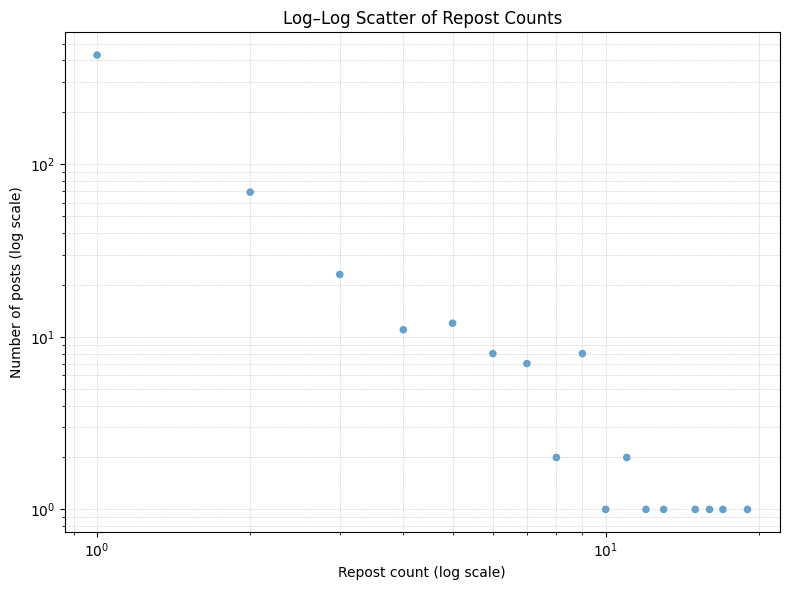

Counter({0: 2421, 1: 430, 2: 69, 3: 23, 5: 12, 4: 11, 9: 8, 6: 8, 7: 7, 8: 2, 11: 2, 16: 1, 19: 1, 10: 1, 12: 1, 17: 1, 13: 1, 15: 1})


In [4]:
hist = repost_scatter("breachdallas.jsonl")
print(hist)

In [ ]:
def plot_bar_from_dict(data, title="Bar Chart", xlabel="X", ylabel="Y"):
    """
    Plot a bar chart using dict keys as x-axis and values as y-axis.

    Args:
        data (dict): {x_value: y_value}
        title (str): Chart title
        xlabel (str): X-axis label
        ylabel (str): Y-axis label
    """
    if not data:
        print("⚠️ No data to plot.")
        return

    # Prepare data
    x = list(data.keys())
    y = list(data.values())

    plt.figure(figsize=(8, 5))
    plt.bar(x, y)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(x)
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()